# ESS experiment result visualization

Following the style of `WT_Solar_result_vis.ipynb`, this notebook analyzes the 280 ESS-enabled experiment runs from multiple perspectives:
- **Part 1**: Imports and parameter setup
- **Part 2**: Load `.npy` or CSV data
- **Part 3**: FICA vs EIFICA paired statistics
- **Part 4**: Solve-time comparison (log y-axis)
- **Part 5**: Out-of-sample satisfaction comparison
- **Part 6**: Speedup boxplots and objective-value differences
- **Part 7**: ESS power and SOC curves for a representative scenario

## Part 1: Imports and parameter setup

In [83]:
import os, re, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
warnings.filterwarnings('ignore', message='.*findfont.*')

#  Academic plotting style WT_Solar_result_vis 
plt.style.use('default')
plt.rcParams.update({
    'font.size': 13,
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Liberation Serif', 'FreeSerif', 'serif'],
    'legend.fontsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'mathtext.fontset': 'cm',
})

#  Experiment parametersconsistent with `run_case24_ess_experiment.py`
method_list         = ['FICA', 'EIFICA']
eps_theta_pair_list = [(0.03, 0.06), (0.05, 0.10), (0.08, 0.12), (0.10, 0.15)]
N_WDR_list          = [50, 80, 100, 150, 200, 250, 300]
seed_list           = [0, 10000, 20000, 30000, 40000]
num_ESS             = 6

#  Path configuration 
cwd = os.getcwd()
if os.path.basename(cwd) == 'case24' and os.path.basename(os.path.dirname(cwd)) == 'case_study_ess_results':
    result_dir = cwd
    project_root = os.path.dirname(os.path.dirname(cwd))
else:
    project_root = cwd
    result_dir = os.path.join(project_root, 'case_study_ess_results', 'case24')
csv_path    = os.path.join(result_dir, 'progress.csv')
fig_dir     = os.path.join(project_root, 'figure', 'case24_ess')
os.makedirs(fig_dir, exist_ok=True)

print(f"Result directory:  {os.path.relpath(result_dir, project_root).replace(os.sep, '/')}")
print(f"Figure directory:  {os.path.relpath(fig_dir, project_root).replace(os.sep, '/')}")
print(f"CSV file:  {os.path.relpath(csv_path, project_root).replace(os.sep, '/')}  exists={os.path.exists(csv_path)}")

Result directory:  case_study_ess_results/case24
Figure directory:  figure/case24_ess
CSV file:  case_study_ess_results/case24/progress.csv  exists=True


## Part 2: Load data (prefer `.npy`, fall back to CSV)

In [84]:
def load_ess_results_from_npy(result_dir):
    """ result_*.npy  ESS """
    rows = []
    pattern = re.compile(
        r'result_case24_ieee_rts_theta([\d.]+)_epsilon([\d.]+)'
        r'_gurobi_seed(\d+)_num_gen\d+_N_WDR(\d+)_.*_(EIFICA|FICA)_.*\.npy'
    )
    for fname in os.listdir(result_dir):
        m = pattern.match(fname)
        if not m:
            continue
        theta, eps, seed, nwdr, method = m.groups()
        data = np.load(os.path.join(result_dir, fname), allow_pickle=True).item()

        rows.append({
            'method':      method,
            'eps':         float(eps),
            'theta':       float(theta),
            'N_WDR':       int(nwdr),
            'seed':        int(seed),
            'num_ESS':     data.get('num_ESS', 6),
            'min_cost':    data.get('min_cost (USD)', np.nan),
            'reliability': data.get('reliability_test (%)', np.nan),  # percentage on the 0-100 scale
            'Time':        data.get('t_solve (s)', np.nan),
            'status':      data.get('status', np.nan),
        })

    df = pd.DataFrame(rows)
    print(f'Loaded from .npy: {len(df)}  records')
    return df


def load_ess_results_from_csv(csv_path):
    """ progress.csv """
    df = pd.read_csv(csv_path)
    df = df.rename(columns={
        'epsilon':        'eps',
        'solve_time':     'Time',
        'obj_value':      'min_cost',
        'satisfied_rate': 'reliability',
    })
    df['reliability'] = df['reliability'] * 100   # convert to percentage
    print(f'Loaded from CSV: {len(df)}  records')
    return df


#  Prefer `.npy`, fall back to CSV 
npy_files = [f for f in os.listdir(result_dir) if f.startswith('result_') and f.endswith('.npy')]
if len(npy_files) > 0:
    df = load_ess_results_from_npy(result_dir)
else:
    print('No `.npy` files found; falling back to CSV ...')
    df = load_ess_results_from_csv(csv_path)

print(f'\nTotal {len(df)} rows x {len(df.columns)} columns')
print(f'Method distribution:\n{df["method"].value_counts()}')
print(f'\nN_WDR distribution:\n{df["N_WDR"].value_counts().sort_index()}')
df.head(5)

Loaded from .npy: 280  records

Total 280 rows x 10 columns
Method distribution:
method
EIFICA    140
FICA      140
Name: count, dtype: int64

N_WDR distribution:
N_WDR
50     40
80     40
100    40
150    40
200    40
250    40
300    40
Name: count, dtype: int64


,method,eps,theta,N_WDR,seed,num_ESS,min_cost,reliability,Time,status
0,EIFICA,0.0300,0.0600,100,0,6,714711.0434,38.9600,46.8646,2
1,FICA,0.0300,0.0600,100,0,6,714731.4742,81.4000,605.2273,2
2,EIFICA,0.0300,0.0600,150,0,6,714844.7788,46.4400,94.5612,2
3,FICA,0.0300,0.0600,150,0,6,714868.5452,89.0200,621.2079,2
4,EIFICA,0.0300,0.0600,200,0,6,714905.3352,91.7000,190.1707,2


## Part 3: FICA vs EIFICA paired statistics

In [85]:
merge_keys = ['eps', 'theta', 'N_WDR', 'seed']
FICA_df   = df[df['method'] == 'FICA'].copy()
EIFICA_df = df[df['method'] == 'EIFICA'].copy()
merged_df = pd.merge(FICA_df, EIFICA_df, on=merge_keys, suffixes=('_FICA', '_EIFICA'))

# Speedup, objective-value difference, and JCC difference
merged_df['speedup']       = merged_df['Time_FICA'] / merged_df['Time_EIFICA']
merged_df['cost_diff_pct'] = (merged_df['min_cost_EIFICA'] - merged_df['min_cost_FICA']) \
                              / merged_df['min_cost_FICA'].abs() * 100
merged_df['jcc_diff']      = merged_df['reliability_EIFICA'] - merged_df['reliability_FICA']

stats = merged_df.groupby(['eps', 'theta', 'N_WDR']).agg(
    speedup_mean  =('speedup',       'mean'),
    speedup_std   =('speedup',       'std'),
    cost_diff_mean=('cost_diff_pct', 'mean'),
    cost_diff_std =('cost_diff_pct', 'std'),
    jcc_diff_mean =('jcc_diff',      'mean'),
    n_pairs       =('speedup',       'count'),
).reset_index()

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
display(stats)

,eps,theta,N_WDR,speedup_mean,speedup_std,cost_diff_mean,cost_diff_std,jcc_diff_mean,n_pairs
0,0.0300,0.0600,50,1.2580,0.0486,-0.0034,0.0031,-46.8440,5
1,0.0300,0.0600,80,1.7011,0.4902,-0.0018,0.0015,-42.9680,5
2,0.0300,0.0600,100,11.4293,1.6679,-0.0013,0.0013,-23.8080,5
3,0.0300,0.0600,150,5.4644,0.8135,-0.0014,0.0016,-12.2920,5
4,0.0300,0.0600,200,5.5414,0.9991,-0.0007,0.0007,-2.0960,5
5,0.0300,0.0600,250,7.3432,0.8656,-0.0006,0.0008,-1.7160,5
6,0.0300,0.0600,300,6.3701,1.8030,-0.0007,0.0008,-2.2240,5
7,0.0500,0.1000,50,1.0787,0.0280,-0.0020,0.0015,-37.5280,5
8,0.0500,0.1000,80,1.1323,0.0296,-0.0004,0.0005,-7.9880,5
9,0.0500,0.1000,100,8.4932,0.6207,-0.0003,0.0005,-0.9520,5


## Part 4: Solve-time comparison (2x2, log y-axis)

Saved: figure/case24_ess/ess_time_comparison.pdf


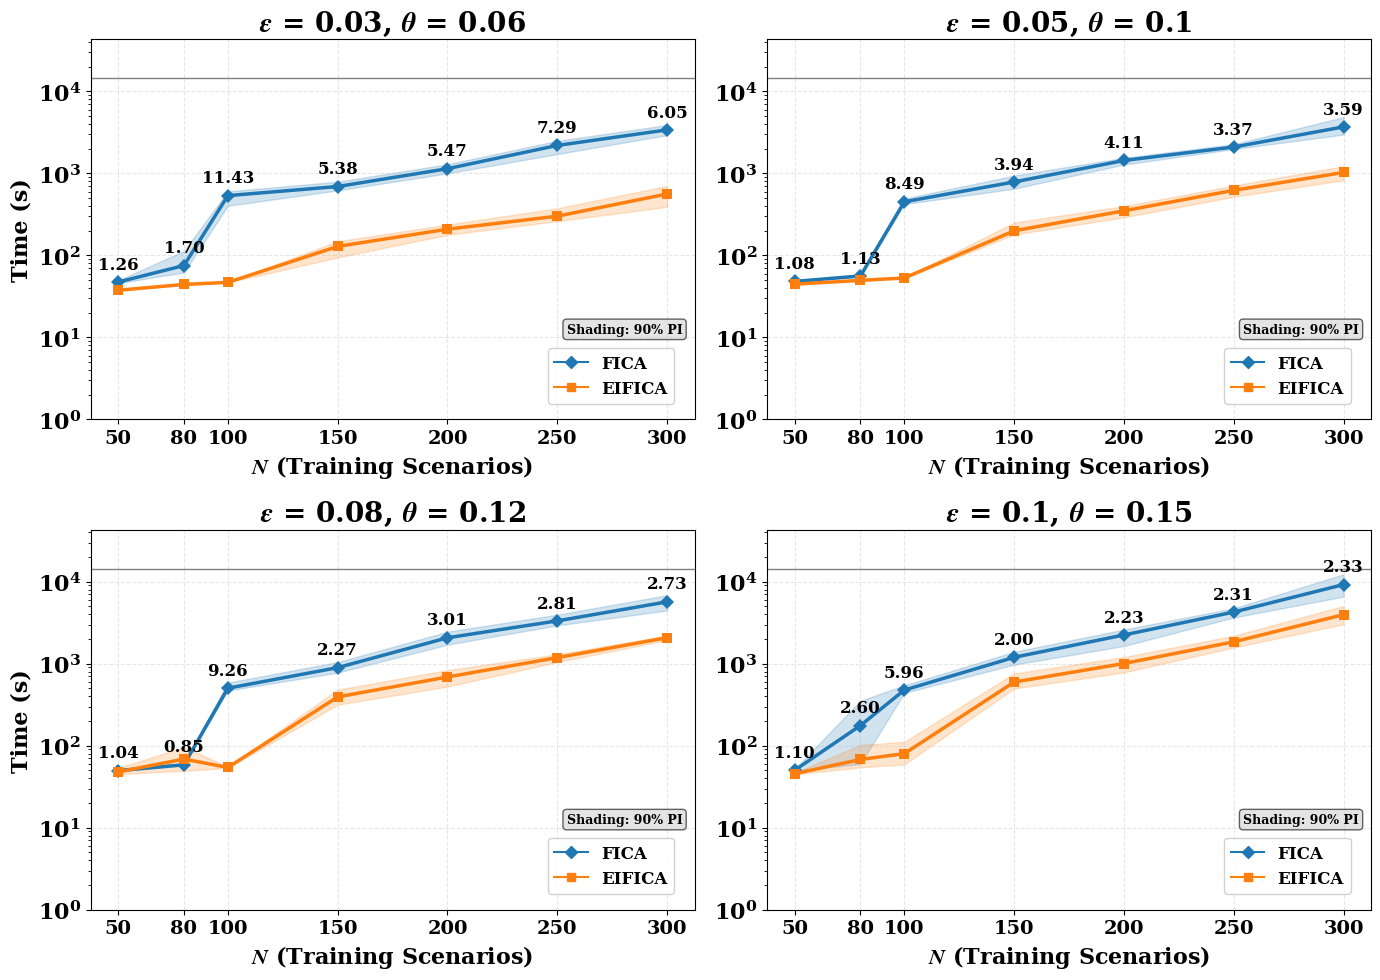

In [86]:
from matplotlib.lines import Line2D

#  Colors and markers aligned with `WT_Solar_result_vis` 
palette = {
    'EIFICA': sns.color_palette('tab10')[1],   # orange
    'FICA':   sns.color_palette('tab10')[0],   # blue
}
marker_map = {'FICA': 'D', 'EIFICA': 's'}
timelimit  = 14400   # consistent with the experiment setup

#  Part 4Solve-time comparison (2x2, log y-axis)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    df_plot = df[(df['eps'] == eps) & (df['theta'] == theta)].copy()

    for method in ['FICA', 'EIFICA']:
        df_m = df_plot[df_plot['method'] == method]
        if not df_m.empty:
            sns.lineplot(
                x='N_WDR', y='Time', data=df_m, ax=ax,
                color=palette[method],
                estimator='mean', errorbar=('pi', 100),
                marker=marker_map[method], n_boot=1000,
                linestyle='-',
                markersize=7, markeredgewidth=0, linewidth=2.5,
            )

    ax.axhline(timelimit, color='black', linestyle='-', alpha=0.5, linewidth=1)

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Time (s)' if i % 2 == 0 else '', fontsize=16, fontweight='bold')
    ax.set_xticks(N_WDR_list)
    ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', which='major', labelsize=16)
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.set_yscale('log')
    ax.set_ylim(1, timelimit * 3)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Speedup annotation
    t_fica   = df_plot[df_plot['method'] == 'FICA'].groupby('N_WDR')['Time'].mean()
    t_eifica = df_plot[df_plot['method'] == 'EIFICA'].groupby('N_WDR')['Time'].mean()
    for n_wdr in t_fica.index.intersection(t_eifica.index):
        spd = t_fica[n_wdr] / t_eifica[n_wdr]
        ax.text(n_wdr, t_fica[n_wdr] * 1.3, f'{spd:.2f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    if ax.get_legend():
        ax.get_legend().remove()

    custom_lines = [
        Line2D([0], [0], color=palette['FICA'],   marker='D', linestyle='-', label='FICA'),
        Line2D([0], [0], color=palette['EIFICA'], marker='s', linestyle='-', label='EIFICA'),
    ]
    ax.legend(custom_lines, ['FICA', 'EIFICA'],
              loc='lower right', bbox_to_anchor=(0.98, 0.02),
              framealpha=0.9, prop={'weight': 'bold', 'size': 12})
    ax.text(0.98, 0.22, 'Shading: 90% PI', transform=ax.transAxes,
            fontsize=9, ha='right', va='bottom', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.6))

plt.tight_layout()
save_path = os.path.join(fig_dir, 'ess_time_comparison.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

## Part 5: Out-of-sample satisfaction comparison

Saved: figure/case24_ess/ess_jcc_comparison.pdf


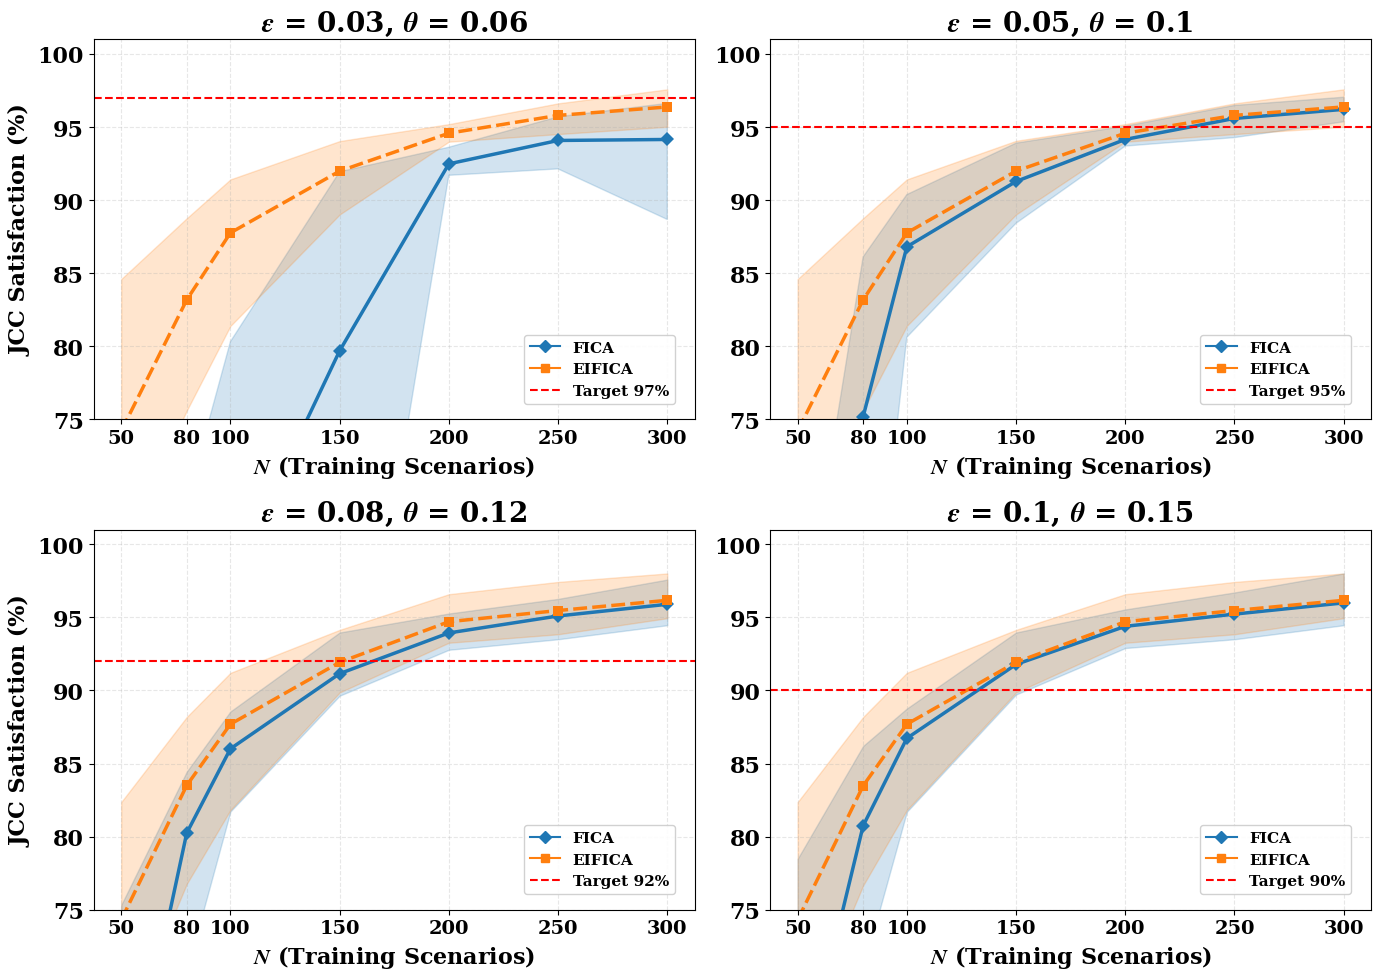

In [87]:
#  Part 5Out-of-sample satisfaction comparison22
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    df_plot = df[(df['eps'] == eps) & (df['theta'] == theta)].copy()

    if not df_plot.empty:
        sns.lineplot(
            x='N_WDR', y='reliability', data=df_plot, ax=ax,
            hue='method', estimator='mean', errorbar=('pi', 100),
            style='method',
            markers=['D', 's'], n_boot=1000,
            markersize=7, markeredgewidth=0, linewidth=2.5,
        )

    target = 100 * (1 - eps)
    ax.axhline(target, color='red', linestyle='--', linewidth=1.5)

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('JCC Satisfaction (%)' if i % 2 == 0 else '', fontsize=16, fontweight='bold')
    ax.set_xticks(N_WDR_list)
    ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', which='major', labelsize=16)
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.set_ylim(75, 101)
    ax.grid(True, linestyle='--', alpha=0.3)

    if ax.get_legend():
        ax.get_legend().remove()

    custom_lines = [
        Line2D([0], [0], color=sns.color_palette('tab10')[0], marker='D', linestyle='-', label='FICA'),
        Line2D([0], [0], color=sns.color_palette('tab10')[1], marker='s', linestyle='-', label='EIFICA'),
        Line2D([0], [0], color='red', linestyle='--', label=f'Target {target:.0f}%'),
    ]
    ax.legend(custom_lines, ['FICA', 'EIFICA', f'Target {target:.0f}%'],
              loc='lower right', bbox_to_anchor=(0.98, 0.02),
              framealpha=0.9, prop={'weight': 'bold', 'size': 11})

plt.tight_layout()
save_path = os.path.join(fig_dir, 'ess_jcc_comparison.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

## Part 6: Speedup boxplots and objective-value differences

Saved: figure/case24_ess/ess_obj_diff.pdf


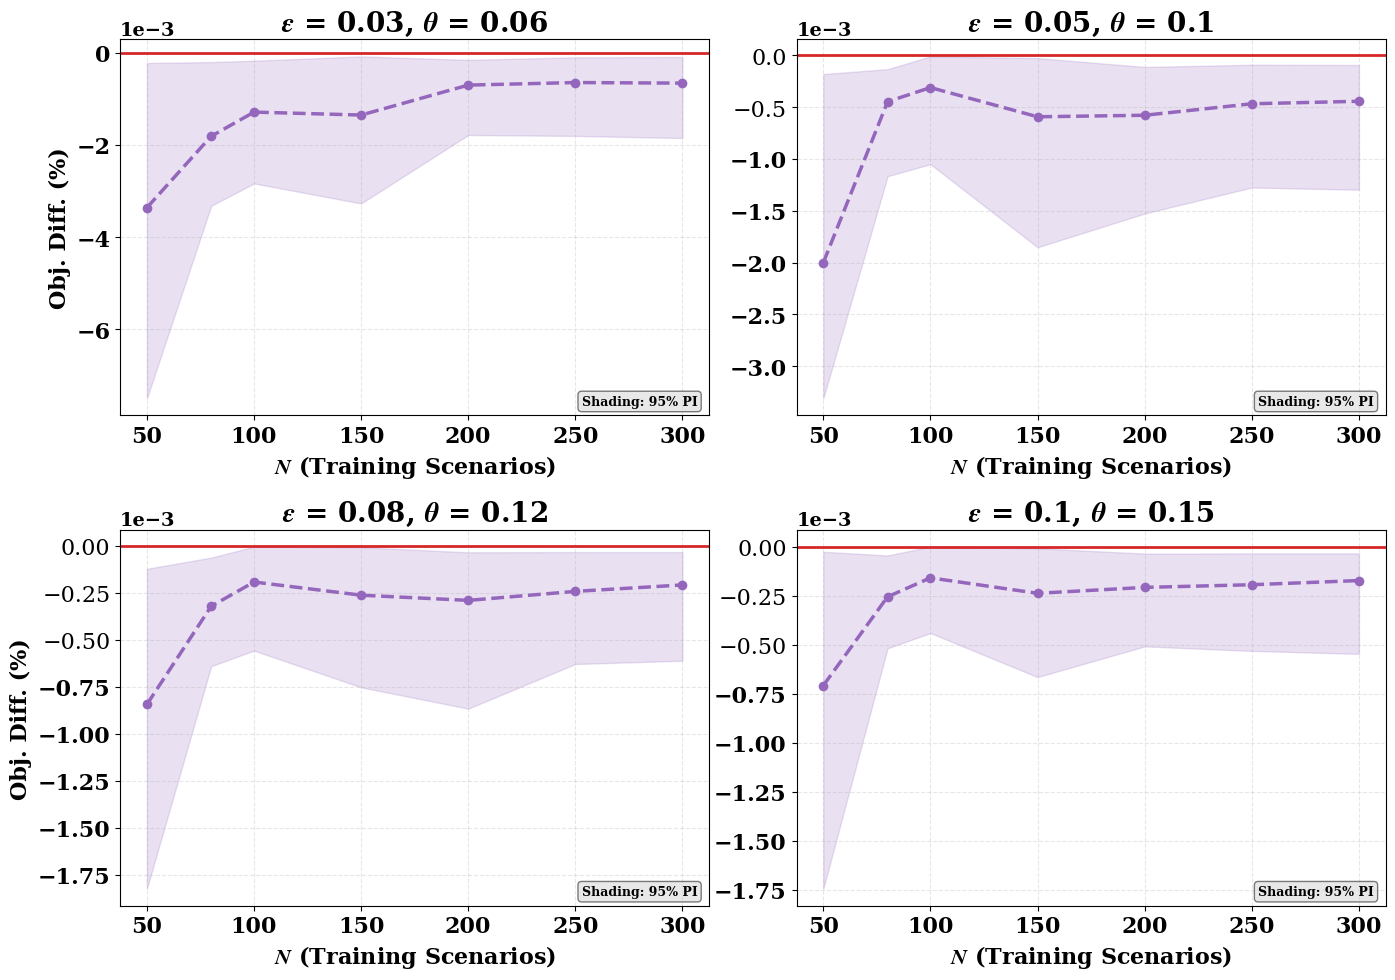

Saved: figure/case24_ess/ess_speedup_boxplot.pdf


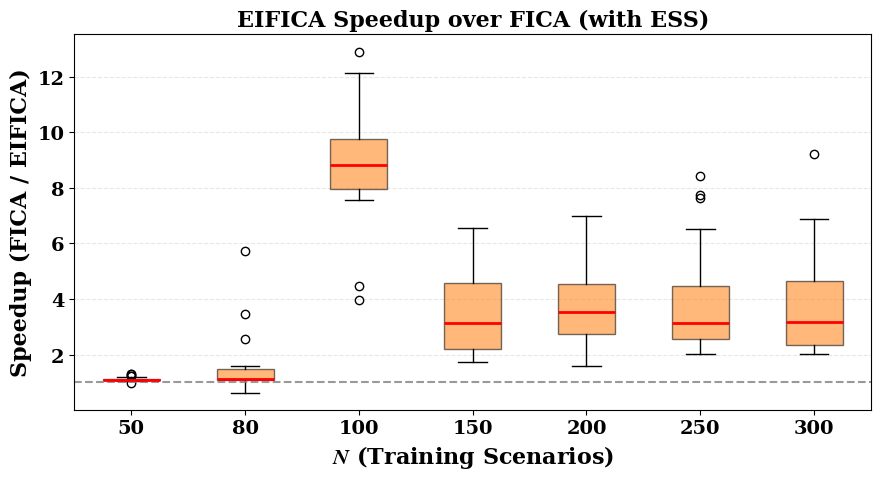

In [88]:
#  Part 6-A % (22aligned with WT_Solar Part 5) 
color_diff = sns.color_palette('tab10')[4]   # purple

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    df_plot = merged_df[(merged_df['eps'] == eps) & (merged_df['theta'] == theta)].copy()

    if not df_plot.empty:
        sns.lineplot(
            x='N_WDR', y='cost_diff_pct', data=df_plot, ax=ax,
            estimator='mean', errorbar=('pi', 95), color=color_diff,
            marker='o', linestyle='--',
            markersize=7, markeredgewidth=0, linewidth=2.5,
        )

    ax.axhline(0, color=sns.color_palette('tab10')[3], linestyle='-', linewidth=2)

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Obj. Diff. (%)' if i % 2 == 0 else '', fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=16)
    plt.setp(ax.get_xticklabels(), fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(-2, 2))
    offset = ax.yaxis.get_offset_text()
    offset.set_fontsize(14)
    offset.set_fontweight('bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.text(0.98, 0.02, 'Shading: 95% PI', transform=ax.transAxes,
            fontsize=9, ha='right', va='bottom', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.tight_layout()
save_path = os.path.join(fig_dir, 'ess_obj_diff.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

#  Part 6-BSpeedup boxplotsaligned with WT_Solar Part 7 
fig, ax = plt.subplots(figsize=(9, 5))

data_box = [merged_df[merged_df['N_WDR'] == n]['speedup'].dropna().values
            for n in N_WDR_list]
ax.boxplot(data_box, positions=range(len(N_WDR_list)), patch_artist=True,
           widths=0.5, showfliers=True,
           medianprops=dict(color='red', linewidth=2),
           boxprops=dict(facecolor=sns.color_palette('tab10')[1], alpha=0.55))
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_xticks(range(len(N_WDR_list)))
ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=14, fontweight='bold')
ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
ax.set_ylabel('Speedup (FICA / EIFICA)', fontsize=16, fontweight='bold')
ax.set_title('EIFICA Speedup over FICA (with ESS)', fontsize=16, fontweight='bold')
ax.tick_params(axis='y', which='major', labelsize=14)
plt.setp(ax.get_yticklabels(), fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(fig_dir, 'ess_speedup_boxplot.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

## Part 7: ESS power and SOC curves for a representative scenario

Select the optimal solution for one parameter setting and plot the scheduled power (`ess_plan_all`) and SOC (`ess_soc`) trajectories of the six ESS units.

Saved: ess_plan_soc_FICA_N150_eps0.1_seed0.png


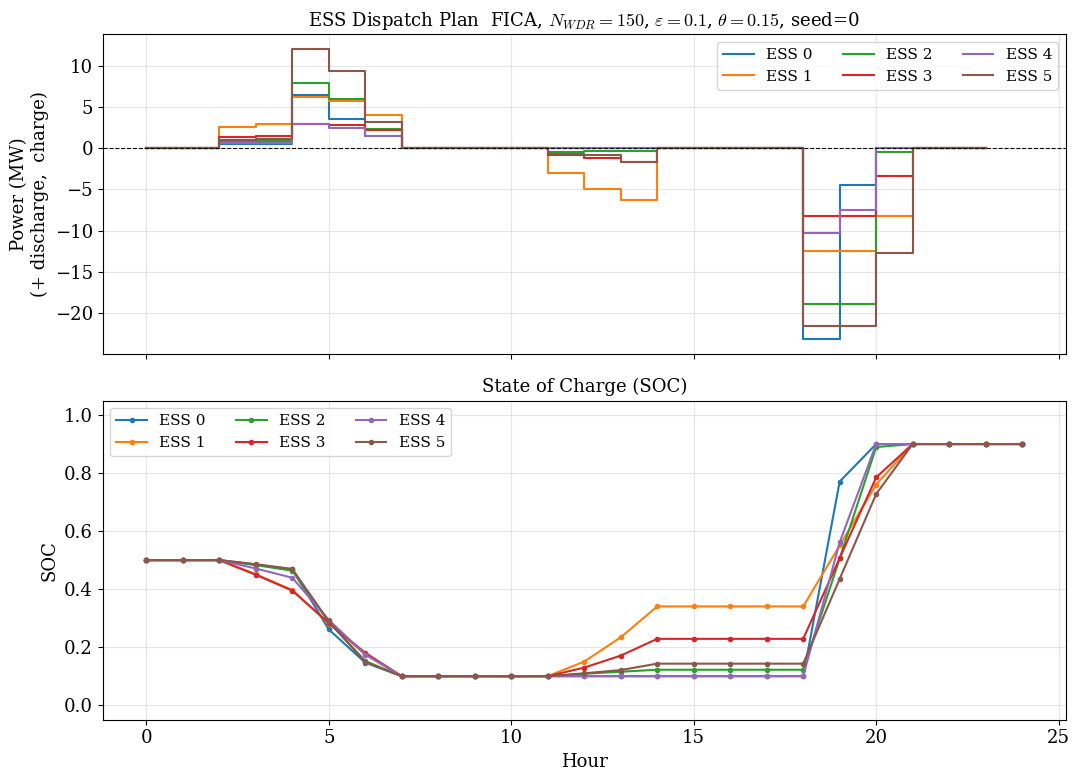

In [89]:
#  Parameter selection (editable)
DEMO_METHOD = 'FICA'
DEMO_EPS    = 0.1
DEMO_THETA  = 0.15
DEMO_NWDR   = 150
DEMO_SEED   = 0

#  Build the `.npy` filename and load it 
demo_fname = (
    f'result_case24_ieee_rts_theta{DEMO_THETA}_epsilon{DEMO_EPS}'
    f'_gurobi_seed{DEMO_SEED}_num_gen38_N_WDR{DEMO_NWDR}'
    f'_load_scaling_factor1_{DEMO_METHOD}_T24_num_Solar5_num_WT10_num_ESS6.npy'
)
demo_path = os.path.join(result_dir, demo_fname)

if not os.path.exists(demo_path):
    print(f'File not found: {demo_fname}')
    print('Please update the parameters above and try again.')
else:
    data = np.load(demo_path, allow_pickle=True).item()
    ess_plan = data['ess_plan_all']   # (T=24, num_ESS=6)  discharge > 0
    ess_soc  = data['ess_soc']        # (T+1=25, num_ESS=6)
    T = ess_plan.shape[0]
    hours = np.arange(T)
    num_ess = ess_plan.shape[1]
    cmap = plt.get_cmap('tab10')

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

    #  Top panel: ESS scheduled power 
    ax = axes[0]
    for i in range(num_ess):
        ax.step(hours, ess_plan[:, i], where='post',
                label=f'ESS {i}', color=cmap(i), linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Power (MW)\n(+ discharge,  charge)', fontsize=13)
    ax.set_title(
        f'ESS Dispatch Plan  {DEMO_METHOD}, $N_{{WDR}}={DEMO_NWDR}$, '
        f'$\\varepsilon={DEMO_EPS}$, $\\theta={DEMO_THETA}$, seed={DEMO_SEED}',
        fontsize=13)
    ax.legend(ncol=3, fontsize=11)
    ax.grid(True, alpha=0.3)

    #  Bottom panel: SOC trajectory 
    ax2 = axes[1]
    for i in range(num_ess):
        ax2.plot(np.arange(T + 1), ess_soc[:, i],
                 label=f'ESS {i}', color=cmap(i), linewidth=1.5, marker='.')
    ax2.set_xlabel('Hour', fontsize=13)
    ax2.set_ylabel('SOC', fontsize=13)
    ax2.set_title('State of Charge (SOC)', fontsize=13)
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(ncol=3, fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    save_name = f'ess_plan_soc_{DEMO_METHOD}_N{DEMO_NWDR}_eps{DEMO_EPS}_seed{DEMO_SEED}.png'
    fig.savefig(os.path.join(fig_dir, save_name), dpi=300, bbox_inches='tight')
    print(f"Saved: {os.path.relpath(save_name, project_root).replace(os.sep, '/')}")
    plt.show()

## Part 8: Optimality gap  EIFICA vs ExactLHS (with ESS)

Compared with the wind-coupled version (`WT_Solar_result_vis.ipynb` Part 9), visualize the objective-value difference (optimality gap) of EIFICA relative to ExactLHS in the ESS setting.  
Data source:`case24_ess_optimality_results/optimality_gap_main.csv`

Reading data: case24_ess_optimality_results/optimality_gap_main.csv
Valid rows: 600  Methods: ['EIFICA', 'ExactLHS']
Valid pairs: 300  diff_pct: [-2.1631%, 0.0008%]
Unified y-axis range: -2.379 ~ 0.217  tick interval: 0.5
Figure saved: case24_ess_optimality_results/optimality_gap_ess_boxplot.pdf


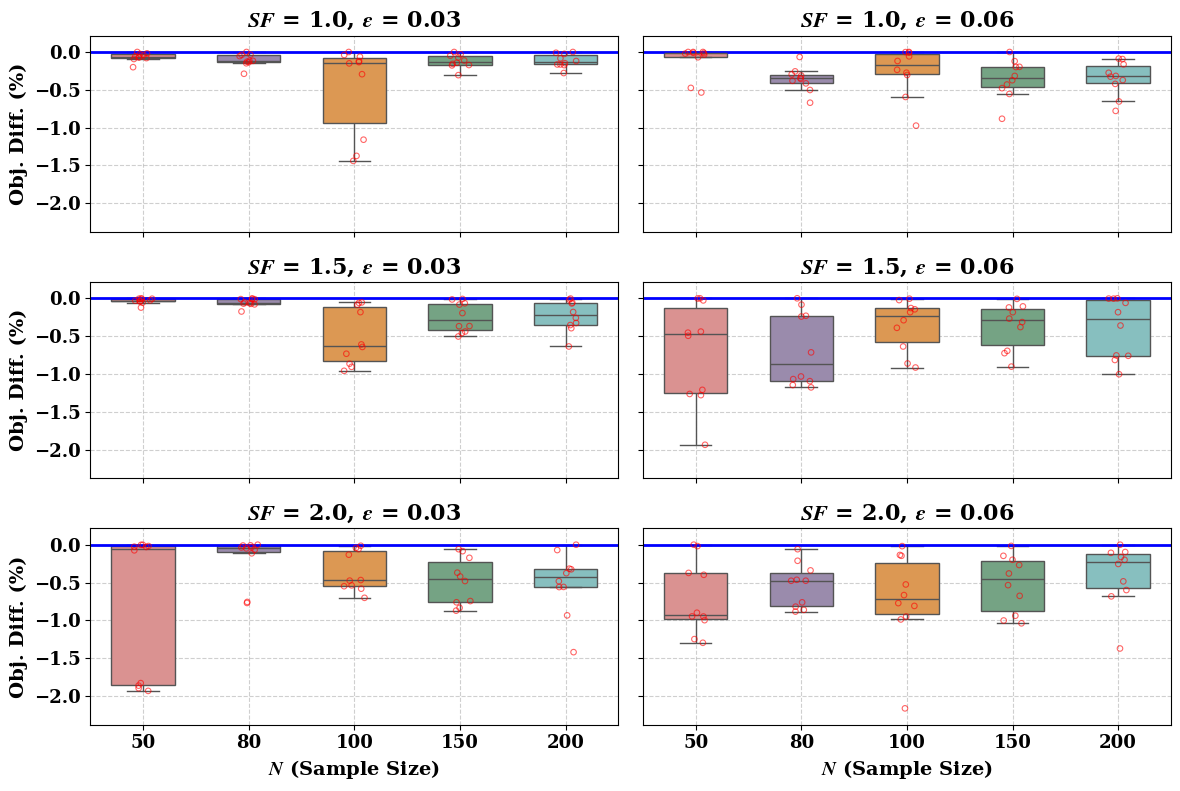

Reading data: case24_ess_optimality_results/optimality_gap_main.csv
Valid rows: 600  Methods: ['EIFICA', 'ExactLHS']
Valid pairs: 300  diff_pct: [-2.1631%, 0.0008%]
Unified y-axis range: -2.379 ~ 0.217  tick interval: 0.5
Figure saved: case24_ess_optimality_results/optimality_gap_ess_violin.pdf


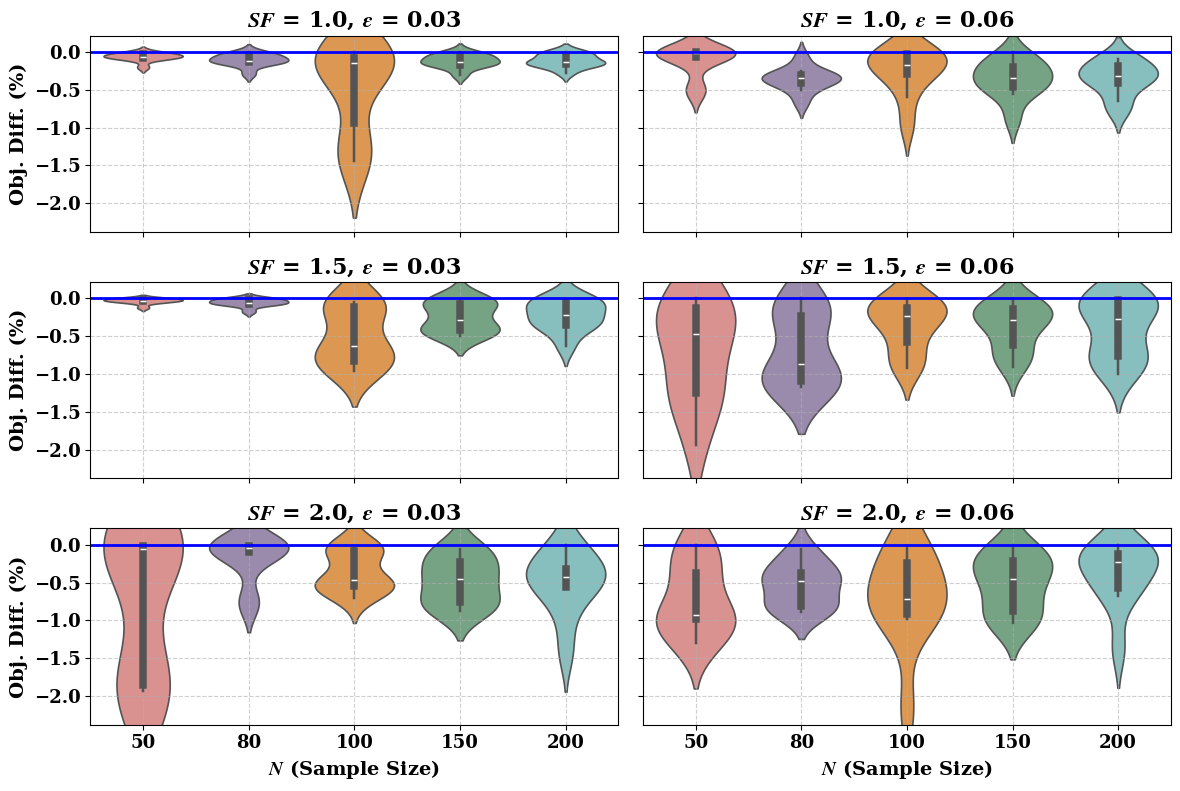

Reading data: case24_ess_optimality_results/optimality_gap_main.csv
Valid rows: 600  Methods: ['EIFICA', 'ExactLHS']
Valid pairs: 300  diff_pct: [-2.1631%, 0.0008%]
Unified y-axis range: -2.379 ~ 0.217  tick interval: 0.5
Figure saved: case24_ess_optimality_results/optimality_gap_ess_raincloud.pdf


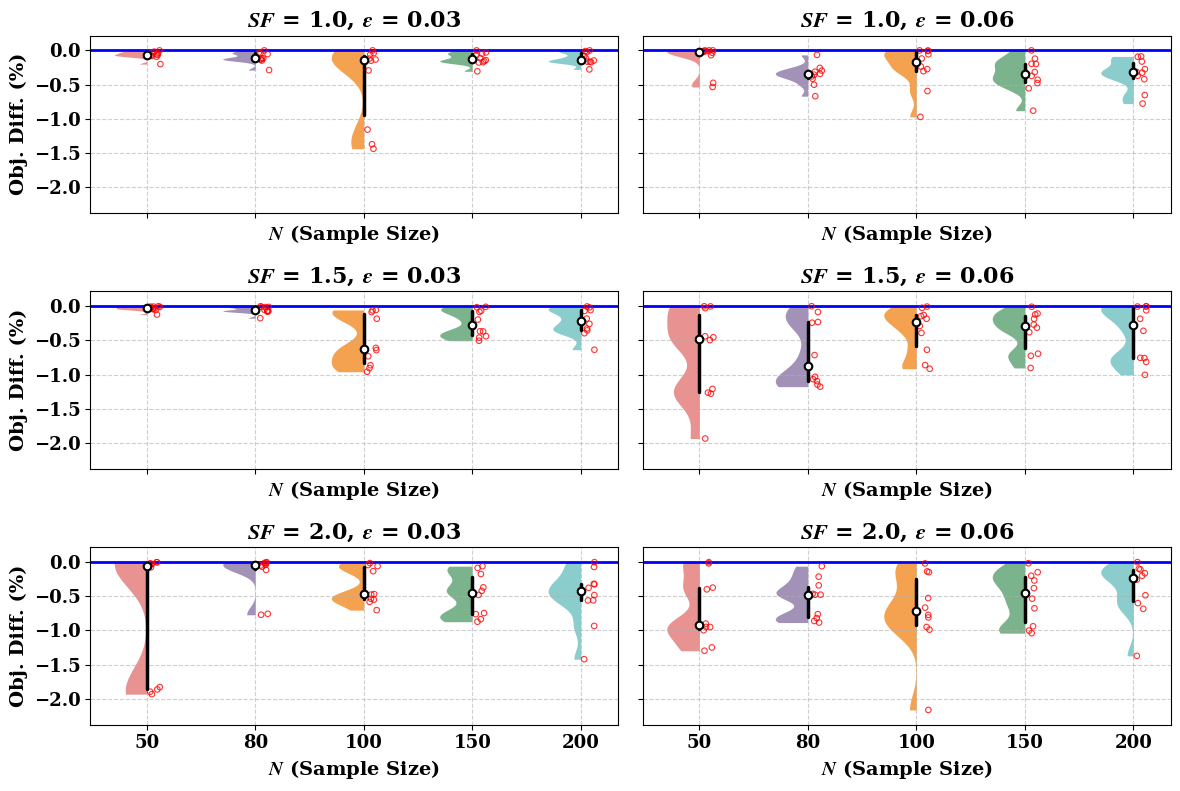

In [90]:
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde

def plot_ess_optimality_gap(
    csv_file=None,
    style='boxplot',   # options: 'boxplot' / 'violin' / 'raincloud'
):
    """
    ESS optimality gap: EIFICA vs ExactLHS
    Layout: rows = SF (3), columns = epsilon (2), for 6 subplots total (theta is fixed and omitted)
    Use a unified y-axis range across all subplots, aligned by the maximum span.
    """
    plt.rcParams['mathtext.fontset'] = 'stix'
    my_palette = ["#E68685", "#9986B1", "#F3983C", "#6DAB81", "#7EC8C8"]
    if csv_file is None:
        csv_file = os.path.join(project_root, 'case24_ess_optimality_results', 'optimality_gap_main.csv')
    elif not os.path.isabs(csv_file):
        csv_file = os.path.join(project_root, csv_file)

    if not os.path.exists(csv_file):
        print(f"File not found: {os.path.relpath(csv_file, project_root).replace(os.sep, '/')}"); return

    print(f"Reading data: {os.path.relpath(csv_file, project_root).replace(os.sep, '/')}")
    df_opt = pd.read_csv(csv_file).dropna(subset=['obj']).drop_duplicates()
    print(f"Valid rows: {len(df_opt)}  Methods: {df_opt['method'].unique().tolist()}")

    # Pairing
    pivoted = df_opt.pivot_table(
        index=['sf', 'epsilon', 'theta', 'n_wdr', 'seed'],
        columns='method', values='obj'
    ).reset_index()

    if 'EIFICA' not in pivoted.columns or 'ExactLHS' not in pivoted.columns:
        print(f"EIFICA or ExactLHS is missing; available columns: {pivoted.columns.tolist()}"); return

    pivoted = pivoted.dropna(subset=['EIFICA', 'ExactLHS'])
    pivoted['diff_pct'] = (pivoted['EIFICA'] - pivoted['ExactLHS']) / pivoted['ExactLHS'].abs() * 100
    print(f"Valid pairs: {len(pivoted)}  diff_pct: [{pivoted['diff_pct'].min():.4f}%, {pivoted['diff_pct'].max():.4f}%]")

    #   y Unify the global y-axis range by applying a 10% margin to the overall min/max 
    global_min = pivoted['diff_pct'].min()
    global_max = pivoted['diff_pct'].max()
    margin = (global_max - global_min) * 0.10
    y_lim = (global_min - margin, global_max + margin)
    # Y-axis tick interval: choose an appropriate interval automatically based on the span
    y_span = y_lim[1] - y_lim[0]
    if y_span <= 3:
        tick_interval = 0.5
    elif y_span <= 6:
        tick_interval = 0.75
    elif y_span <= 12:
        tick_interval = 1.5
    else:
        tick_interval = 3.0
    print(f"Unified y-axis range: {y_lim[0]:.3f} ~ {y_lim[1]:.3f}  tick interval: {tick_interval}")

    SF_list  = sorted(pivoted['sf'].unique())
    EPS_list = sorted(pivoted['epsilon'].unique())

    fig, axes = plt.subplots(len(SF_list), len(EPS_list),
                             figsize=(6 * len(EPS_list), 4.5 * 0.6 * len(SF_list)),
                             sharex=True, sharey=True)   # `sharey=True` keeps the y-axis consistent

    if len(SF_list) == 1 and len(EPS_list) == 1:
        axes = np.array([[axes]])
    elif len(SF_list) == 1:
        axes = axes.reshape(1, -1)
    elif len(EPS_list) == 1:
        axes = axes.reshape(-1, 1)

    rng = np.random.RandomState(42)

    for i, sf in enumerate(SF_list):
        for j, eps in enumerate(EPS_list):
            ax = axes[i, j]
            subset = pivoted[(pivoted['sf'] == sf) & (pivoted['epsilon'] == eps)].copy()

            if subset.empty:
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                        ha='center', va='center', fontsize=12, color='gray')
            else:
                n_wdr_vals = sorted(subset['n_wdr'].unique())
                pal = {nw: my_palette[k % len(my_palette)] for k, nw in enumerate(n_wdr_vals)}

                if style == 'boxplot':
                    sns.boxplot(x='n_wdr', y='diff_pct', data=subset, ax=ax,
                                palette=pal, hue='n_wdr', legend=False,
                                order=n_wdr_vals, width=0.6, showfliers=False)
                    sns.stripplot(x='n_wdr', y='diff_pct', data=subset, ax=ax,
                                  order=n_wdr_vals,
                                  color='none', edgecolor='red', linewidth=0.8,
                                  alpha=0.6, jitter=True, size=4)

                elif style == 'violin':
                    sns.violinplot(x='n_wdr', y='diff_pct', data=subset, ax=ax,
                                   palette=pal, hue='n_wdr', legend=False,
                                   order=n_wdr_vals, inner='box', width=0.75, linewidth=1.2)

                elif style == 'raincloud':
                    for k, nw in enumerate(n_wdr_vals):
                        color = my_palette[k % len(my_palette)]
                        vals = subset[subset['n_wdr'] == nw]['diff_pct'].dropna().values
                        pos = k
                        if len(vals) >= 2:
                            kde = gaussian_kde(vals, bw_method=0.35)
                            ys = np.linspace(vals.min(), vals.max(), 200)
                            density = kde(ys)
                            density = density / density.max() * 0.3
                            ax.fill_betweenx(ys, pos, pos - density,
                                             color=color, alpha=0.9, linewidth=0)
                        jitter = rng.uniform(-0.05, 0.05, size=len(vals))
                        ax.scatter(pos + 0.08 + jitter, vals,
                                   color='none', edgecolors='red',
                                   linewidths=0.8, s=16, alpha=0.8, zorder=3)
                        q25, q50, q75 = np.percentile(vals, [25, 50, 75])
                        ax.plot([pos, pos], [q25, q75], color='k', linewidth=2.5,
                                zorder=4, solid_capstyle='round')
                        ax.scatter([pos], [q50], color='white', edgecolors='k',
                                   linewidths=1.5, s=30, zorder=5)
                    ax.set_xticks(range(len(n_wdr_vals)))
                    ax.set_xticklabels([str(n) for n in n_wdr_vals],
                                       fontweight='bold', fontsize=13)

                ax.axhline(0, color='blue', linestyle='-', linewidth=2)

            #  Unified y-axis range 
            ax.set_ylim(y_lim)
            ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_interval))

            ax.set_title(
                rf'$\boldsymbol{{SF}}$ = {sf}, $\boldsymbol{{\epsilon}}$ = {eps}',
                fontsize=16, fontweight='bold')
            ax.set_xlabel(r'$\boldsymbol{N}$ (Sample Size)', fontsize=14, fontweight='bold')
            ax.set_ylabel('Obj. Diff. (%)' if j == 0 else '', fontsize=14, fontweight='bold')
            ax.tick_params(axis='both', which='major', labelsize=13)
            plt.setp(ax.get_xticklabels(), fontweight='bold')
            plt.setp(ax.get_yticklabels(), fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    save_dir = os.path.join(project_root, 'case24_ess_optimality_results')
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'optimality_gap_ess_{style}.pdf')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
    plt.show()


plot_ess_optimality_gap(style='boxplot')
plot_ess_optimality_gap(style='violin')
plot_ess_optimality_gap(style='raincloud')

## Part 9: ESS benefit validation  cost and satisfaction comparison with and without ESS

**Core hypothesis**After adding ESS, system operating cost should decrease ($\Delta C > 0$) and the out-of-sample satisfaction rate should improve.

$$\Delta C(\%) = \frac{C_{\text{no ESS}} - C_{\text{with ESS}}}{C_{\text{no ESS}}} \times 100\%$$

Data source:
- Without ESS`case24_wt_solar_results/result_*.npy`
- With ESS`case_study_ess_results/case24/result_*.npy`

Without ESS: 280  records    With ESS: 280  records
Valid pairs: 280  records

Cost reduction rate C(%):
N_WDR     50     80     100    150    200    250    300
method                                                 
EIFICA 0.8470 0.8590 0.8680 0.8770 0.8890 0.8940 0.8990
FICA   0.8500 0.8620 0.8700 0.8790 0.8910 0.8960 0.9010

JCC Satisfaction-rate improvement (pp):
N_WDR      50      80      100    150    200    250    300
method                                                    
EIFICA 15.3800 12.4140 12.5380 7.6700 5.2230 4.1020 3.2920
FICA    5.1070  4.8540  4.2700 3.8850 3.3480 2.6380 2.3070
Saved: figure/case24_ess/ess_cost_reduction.pdf


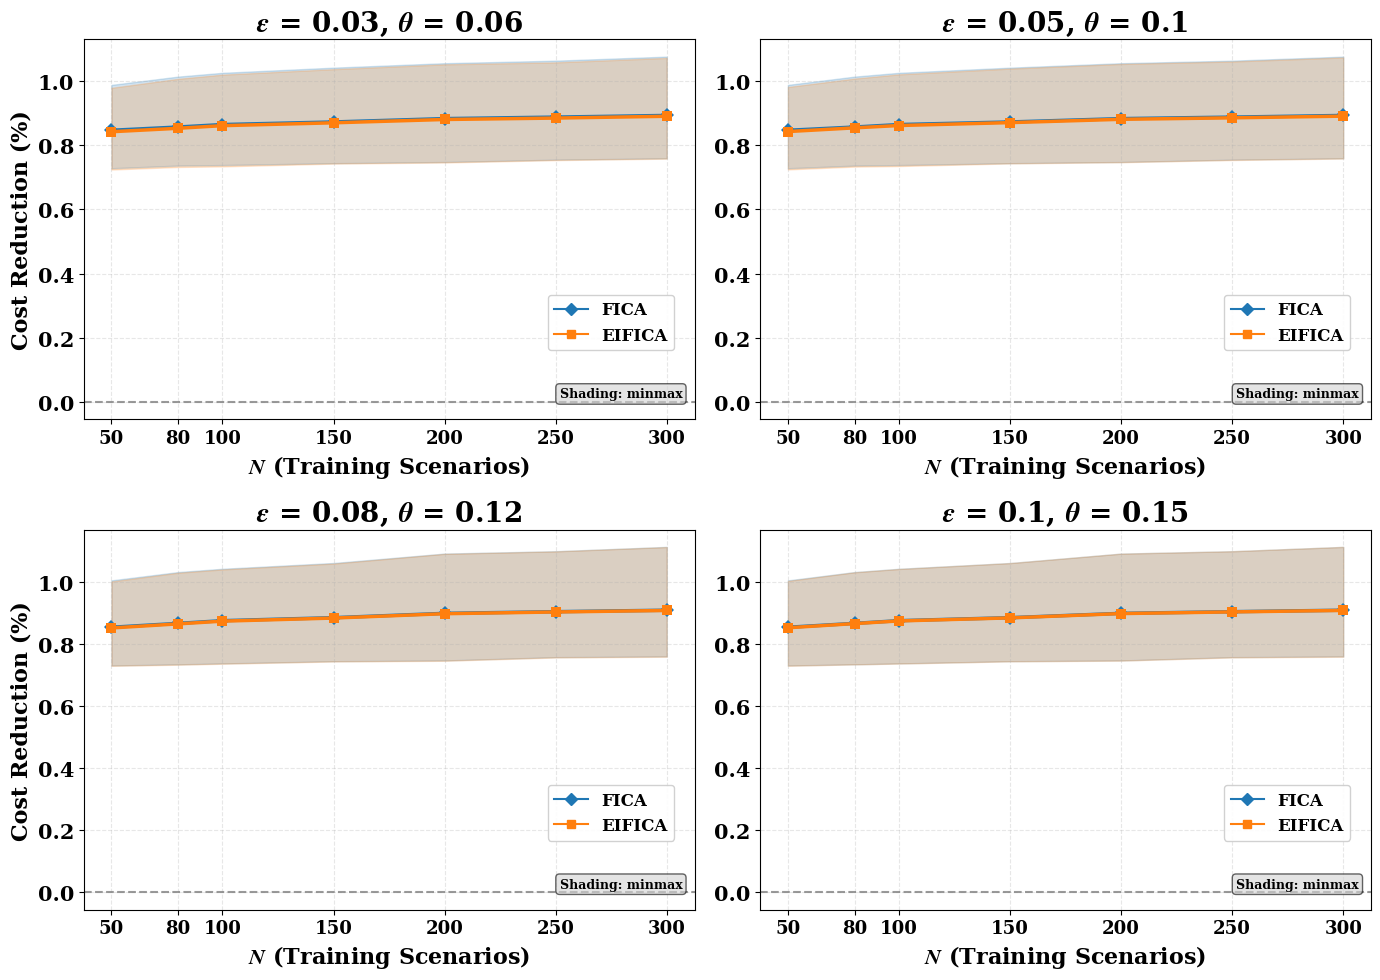

Saved: figure/case24_ess/ess_jcc_improvement.pdf


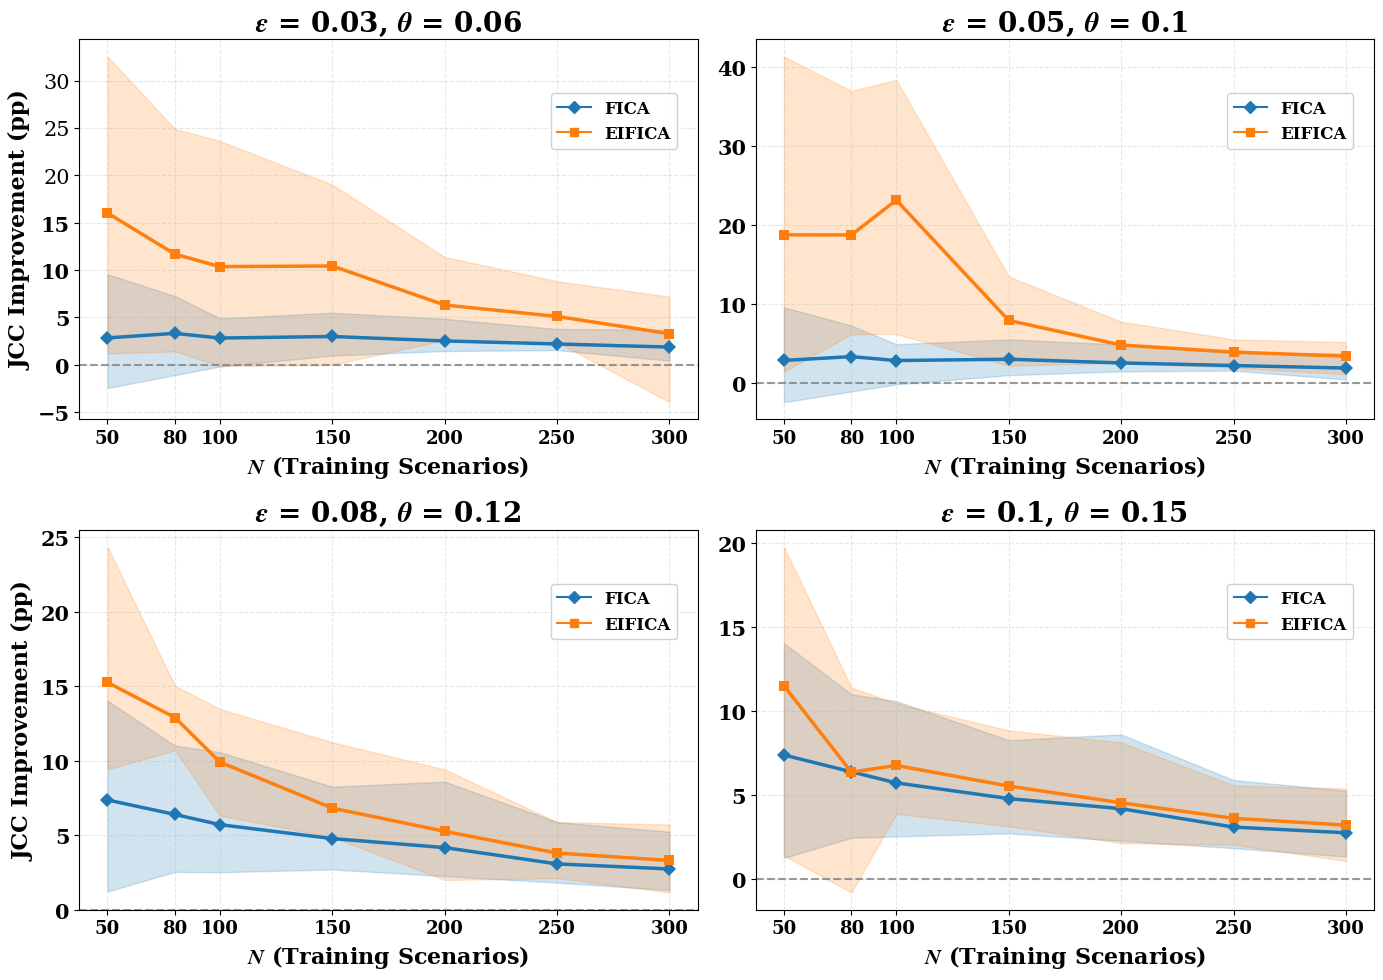

In [91]:
from matplotlib.lines import Line2D

#  Path 
no_ess_dir  = os.path.join(project_root, 'case24_wt_solar_results')
ess_dir     = result_dir

pattern_no  = re.compile(
    r'result_case24_ieee_rts_theta([\d.]+)_epsilon([\d.]+)'
    r'_gurobi_seed(\d+)_num_gen\d+_N_WDR(\d+)_.*_(EIFICA|FICA)_T24_.*\.npy'
)
pattern_ess = re.compile(
    r'result_case24_ieee_rts_theta([\d.]+)_epsilon([\d.]+)'
    r'_gurobi_seed(\d+)_num_gen\d+_N_WDR(\d+)_.*_(EIFICA|FICA)_T24_.*_num_ESS6\.npy'
)

def load_dir(dirpath, pattern):
    rows = []
    for fname in os.listdir(dirpath):
        m = pattern.match(fname)
        if not m:
            continue
        theta, eps, seed, nwdr, method = m.groups()
        d = np.load(os.path.join(dirpath, fname), allow_pickle=True).item()
        rows.append({
            'method':      method,
            'eps':         float(eps),
            'theta':       float(theta),
            'N_WDR':       int(nwdr),
            'seed':        int(seed),
            'min_cost':    d.get('min_cost (USD)', np.nan),
            'reliability': d.get('reliability_test (%)', np.nan),
        })
    return pd.DataFrame(rows)

df_no  = load_dir(no_ess_dir, pattern_no)
df_ess = load_dir(ess_dir,    pattern_ess)
print(f'Without ESS: {len(df_no)}  records    With ESS: {len(df_ess)}  records')

#  PairingAlign by `(method, eps, theta, N_WDR, seed)` 
keys = ['method', 'eps', 'theta', 'N_WDR', 'seed']
comp = pd.merge(df_no, df_ess, on=keys, suffixes=('_no', '_ess'))
comp = comp.dropna(subset=['min_cost_no', 'min_cost_ess'])

comp['cost_reduce_pct'] = (comp['min_cost_no'] - comp['min_cost_ess']) \
                           / comp['min_cost_no'].abs() * 100
comp['jcc_improve']     = comp['reliability_ess'] - comp['reliability_no']

print(f'Valid pairs: {len(comp)}  records')
print(f'\nCost reduction rate C(%):\n{comp.groupby(["method","N_WDR"])["cost_reduce_pct"].mean().unstack().round(3)}')
print(f'\nJCC Satisfaction-rate improvement (pp):\n{comp.groupby(["method","N_WDR"])["jcc_improve"].mean().unstack().round(3)}')

# 
# 1Cost reduction rate C(%)  22 subplots eps/theta
# 
pal_method = {
    'FICA':   sns.color_palette('tab10')[0],
    'EIFICA': sns.color_palette('tab10')[1],
}
mk = {'FICA': 'D', 'EIFICA': 's'}

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    sub = comp[(comp['eps'] == eps) & (comp['theta'] == theta)]

    for method in ['FICA', 'EIFICA']:
        df_m = sub[sub['method'] == method]
        if not df_m.empty:
            sns.lineplot(
                x='N_WDR', y='cost_reduce_pct', data=df_m, ax=ax,
                color=pal_method[method],
                estimator='mean', errorbar=('pi', 100),
                marker=mk[method], n_boot=1000,
                linestyle='-', markersize=7, markeredgewidth=0, linewidth=2.5,
            )

    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Cost Reduction (%)' if i % 2 == 0 else '', fontsize=16, fontweight='bold')
    ax.set_xticks(N_WDR_list)
    ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', which='major', labelsize=15)
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

    if ax.get_legend():
        ax.get_legend().remove()
    custom_lines = [
        Line2D([0],[0], color=pal_method['FICA'],   marker='D', linestyle='-', label='FICA'),
        Line2D([0],[0], color=pal_method['EIFICA'], marker='s', linestyle='-', label='EIFICA'),
    ]
    ax.legend(custom_lines, ['FICA','EIFICA'],
              loc='upper right', bbox_to_anchor=(0.98, 0.35),
              bbox_transform=ax.transAxes,
              framealpha=0.9, prop={'weight':'bold','size':12})
    ax.text(0.98, 0.05, 'Shading: minmax', transform=ax.transAxes,
            fontsize=9, ha='right', va='bottom', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.6))

# plt.suptitle('Cost Reduction: with ESS vs without ESS\n'
#              r'$\Delta C(\%) = (C_{\rm no\,ESS} - C_{\rm with\,ESS})\,/\,C_{\rm no\,ESS} \times 100\%$',
#              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = os.path.join(fig_dir, 'ess_cost_reduction.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()

# 
# 2JCC Satisfaction-rate improvement (pp)  22 subplots
# 
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (eps, theta) in enumerate(eps_theta_pair_list):
    ax = axs[i]
    sub = comp[(comp['eps'] == eps) & (comp['theta'] == theta)]

    for method in ['FICA', 'EIFICA']:
        df_m = sub[sub['method'] == method]
        if not df_m.empty:
            sns.lineplot(
                x='N_WDR', y='jcc_improve', data=df_m, ax=ax,
                color=pal_method[method],
                estimator='mean', errorbar=('pi', 100),
                marker=mk[method], n_boot=1000,
                linestyle='-', markersize=7, markeredgewidth=0, linewidth=2.5,
            )

    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(
        rf'$\boldsymbol{{\epsilon}}$ = {eps}, $\boldsymbol{{\theta}}$ = {theta}',
        fontsize=20, fontweight='bold')
    ax.set_xlabel(r'$\boldsymbol{N}$ (Training Scenarios)', fontsize=16, fontweight='bold')
    ax.set_ylabel('JCC Improvement (pp)' if i % 2 == 0 else '', fontsize=16, fontweight='bold')
    ax.set_xticks(N_WDR_list)
    ax.set_xticklabels([str(n) for n in N_WDR_list], fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', which='major', labelsize=15)
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

    if ax.get_legend():
        ax.get_legend().remove()
    ax.legend(custom_lines, ['FICA','EIFICA'],
              loc='upper right', bbox_to_anchor=(0.98, 0.88),
              bbox_transform=ax.transAxes,
              framealpha=0.9, prop={'weight':'bold','size':12})

# plt.suptitle('JCC Satisfaction Rate Improvement: with ESS vs without ESS\n'
#              r'$\Delta\text{JCC} = \text{JCC}_{\rm with\,ESS} - \text{JCC}_{\rm no\,ESS}$ (pp)',
#              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = os.path.join(fig_dir, 'ess_jcc_improvement.pdf')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.relpath(save_path, project_root).replace(os.sep, '/')}")
plt.show()